# Parameter testing on Total Deep Variation

In [20]:
# requeriments
import os
import sys
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)
import imageio
import numpy as np
import torch
import model
import matplotlib.pyplot as plt
from denoise import psnr, apply_vn
from skimage.metrics import structural_similarity as ssim

## Setup

In [42]:
def check_color(raw_image):
    y = None
    color = None
    if raw_image.ndim == 2: 
        color = "gray"
        y = np.mean(raw_image, 2, keepdims=True)
    else: 
        color = "color"
        y = raw_image[:, :, :3] # chop down 3 channels

    return y, color

def load_model(color):
    # load the model state dict
    checkpoint = torch.load(os.path.join('..', 'checkpoints', f'tdv3-3-25-f32-{color}.pth'), map_location=torch.device('cpu'))

    # get the variational network with the TDV regularizer
    vn = model.VNet(checkpoint['config'], efficient=False)
    vn.load_state_dict(checkpoint['model'])

    return vn, checkpoint
    

def test_img(vn, img_path, sigma, add_noise=True, noisy_img_path=None, n_bits = 8):
    max_value = 2**n_bits - 1
    sigma_ref = 25
    if add_noise:
        img = imageio.v2.imread(img_path).astype(np.float32) / max_value
        y, color = check_color(img)
        z = y + sigma / max_value * np.random.randn(*y.shape).astype(np.float32)

    else:
        noisy_img = imageio.v2.imread(noisy_img_path).astype(np.float32) / max_value
        z, color = check_color(noisy_img)
        y = None # no ground truth img

    # push the images to torch
    y_th = torch.from_numpy(np.transpose(y, (2,0,1))[None])
    z_th = torch.from_numpy(np.transpose(z, (2,0,1))[None])

    with torch.no_grad():
        x_th = apply_vn(z_th, z_th, vn, sigma, sigma_ref)
    x_S = np.transpose(x_th[-1][0].cpu().numpy(), (1,2,0))

    return z, x_S, y

In [43]:
# get the variational network with the TDV regularizer
vn, checkpoint = load_model("color")

# check checkpoint and learned params
print(checkpoint['config'])
print("S:", vn.S)
print("T:", vn.T.item())
print("lambda:", vn.lmbda.item())

{'S': 10, 'R': {'type': 'tdv', 'config': {'in_channels': 3, 'out_channels': 1, 'num_features': 32, 'num_scales': 3, 'num_mb': 3, 'multiplier': 1, 'efficient': True}}, 'D': {'type': 'denoise', 'config': {'use_prox': True}}, 'T_mode': 'learned', 'T': {'init': 0.001, 'min': 0, 'max': 1000}, 'lambda_mode': 'learned', 'lambda': {'init': 0.01, 'min': 0, 'max': 1000}, 'pad': 0}
S: 10
T: 0.024726811796426773
lambda: 0.1045219898223877


In [ ]:
# get the variational network with the TDV regularizer
vn_gray, checkpoint = load_model("gray")

# check checkpoint and learned params
print(checkpoint['config'])
print("S:", vn.S)
print("T:", vn.T.item())
print("lambda:", vn.lmbda.item())

{'S': 10, 'R': {'type': 'tdv', 'config': {'in_channels': 1, 'out_channels': 1, 'num_features': 32, 'num_scales': 3, 'num_mb': 3, 'multiplier': 1, 'efficient': True}}, 'D': {'type': 'denoise', 'config': {'use_prox': True}}, 'T_mode': 'learned', 'T': {'init': 0.001, 'min': 0, 'max': 1000}, 'lambda_mode': 'learned', 'lambda': {'init': 0.01, 'min': 0, 'max': 1000}, 'pad': 0}
S: 10
T: 0.017222747206687927
lambda: 0.2169065624475479


In [45]:
def plot_results(z, x_S, y=None, sigma=25):

    """
    z: noisy image
    x_S: denoised image
    y: ground truth
    """

    if y is not None:

        fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(14, 10))

        ax[0].imshow(np.clip(z, 0, 1))
        ax[0].set_title(rf'z ($\sigma$={sigma})')
        ax[0].set_xlabel(f'PSNR={psnr(z,y):.2f}dB, 'f'SSIM={ssim(z,y,data_range=1,channel_axis=2):.4f}')
        ax[1].imshow(np.clip(x_S, 0, 1))
        ax[1].set_title('x_S')
        ax[1].set_xlabel(f'PSNR={psnr(x_S,y):.2f}dB, 'f'SSIM={ssim(x_S,y,data_range=1,channel_axis=2):.4f}')
        ax[2].imshow(np.clip(y, 0, 1))
        ax[2].set_title('y')

    else:

        fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(15, 5))

        ax[0].imshow(np.clip(z, 0, 1))
        ax[0].set_title('Noisy')
        ax[1].imshow(np.clip(x_S, 0, 1))
        ax[1].set_title('Denoised')

    plt.show()

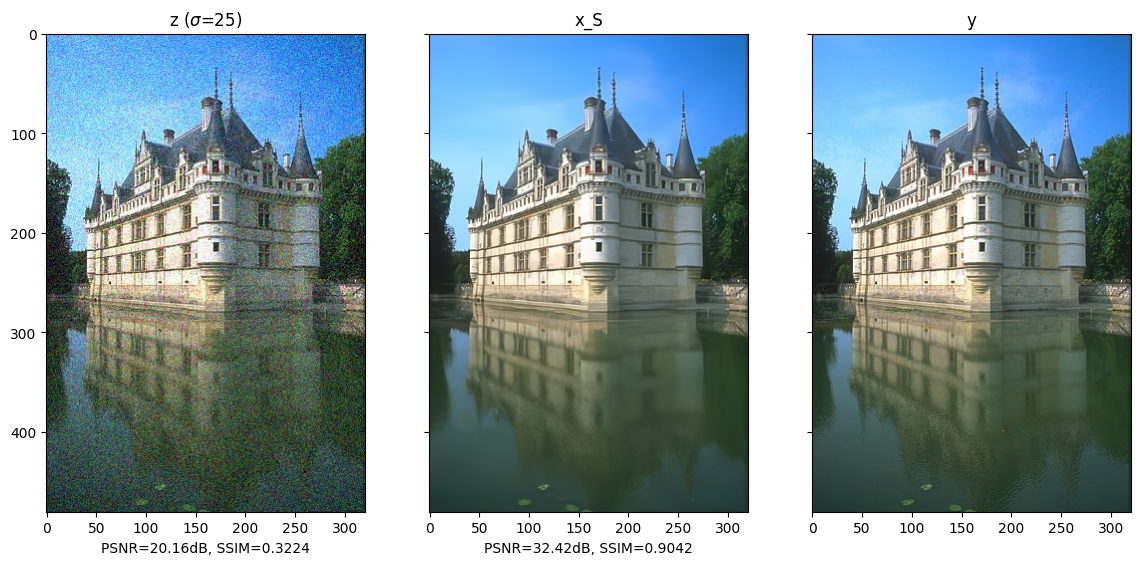

In [46]:
# Plot one img
vn, checkpoint = load_model("color")
img_path = os.path.join('..', 'data', 'water-castle.png')
z, x, y = test_img(vn, img_path, sigma= 25)
plot_results(z, x, y, sigma = 25)

## Sigma values

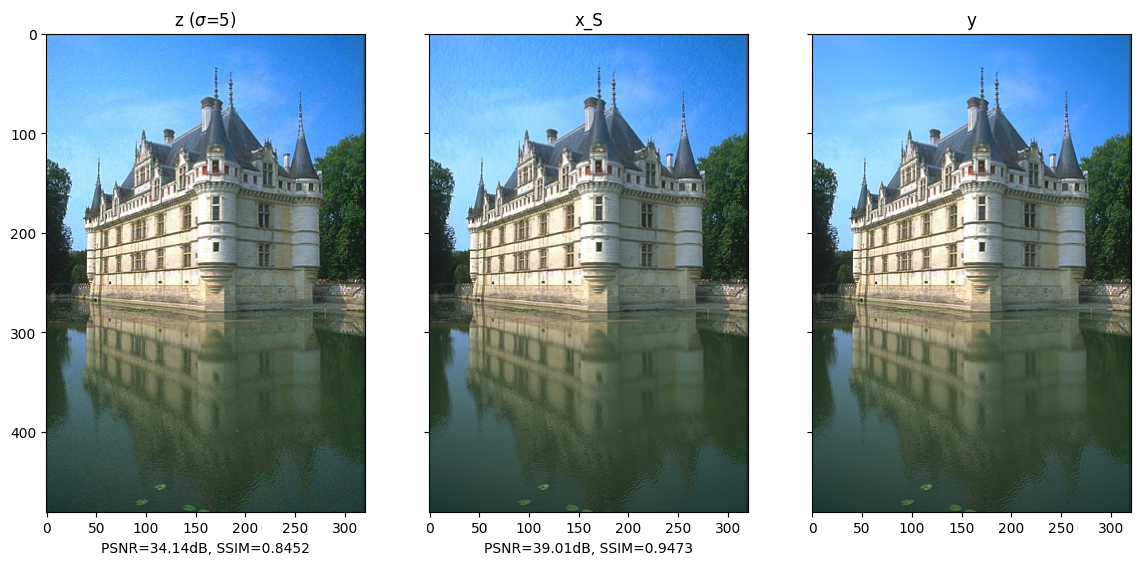

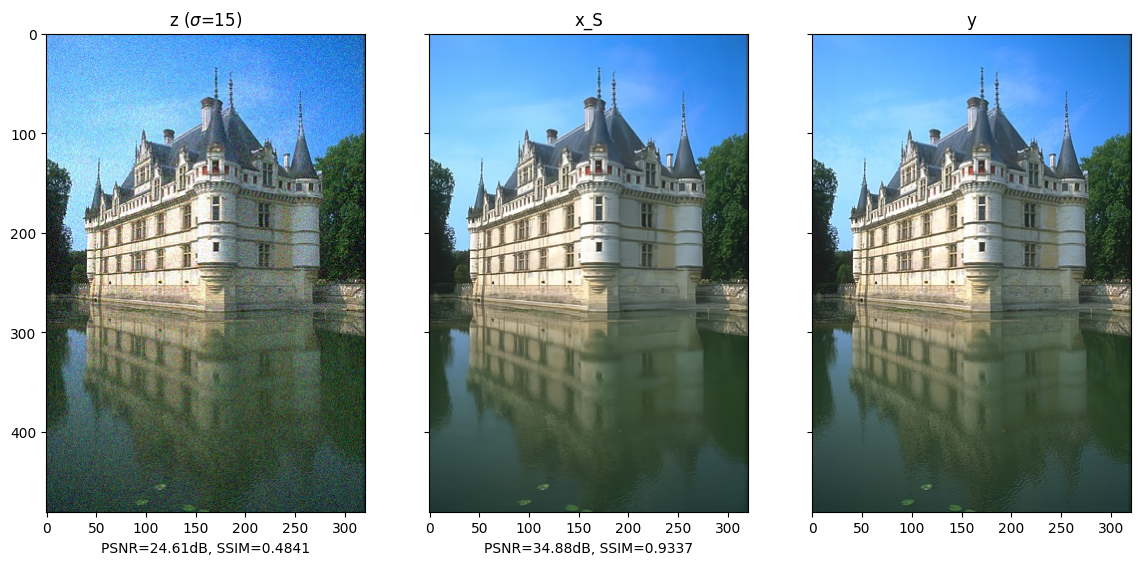

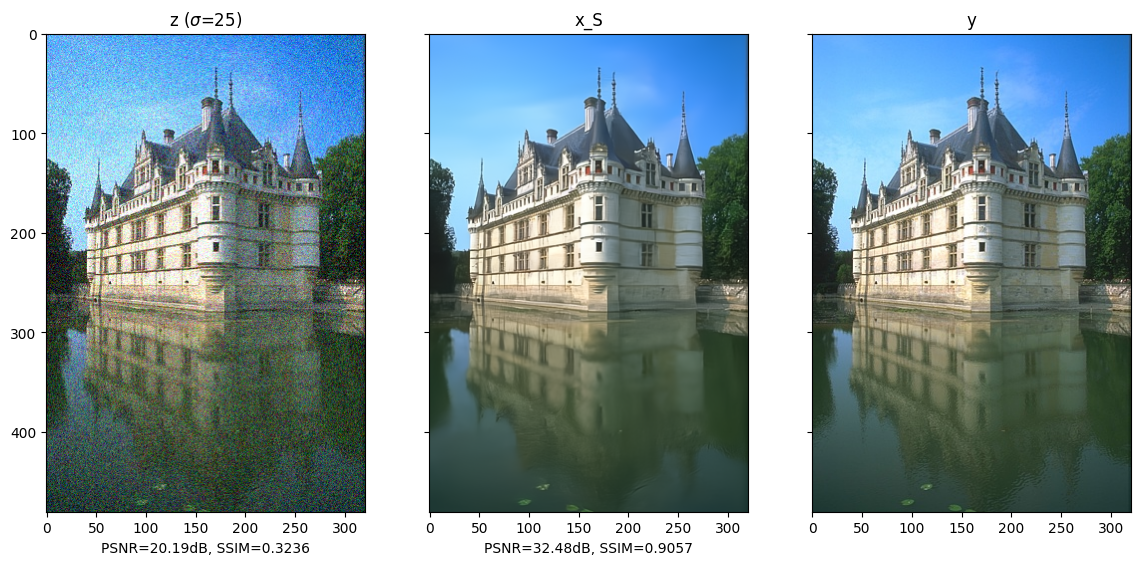

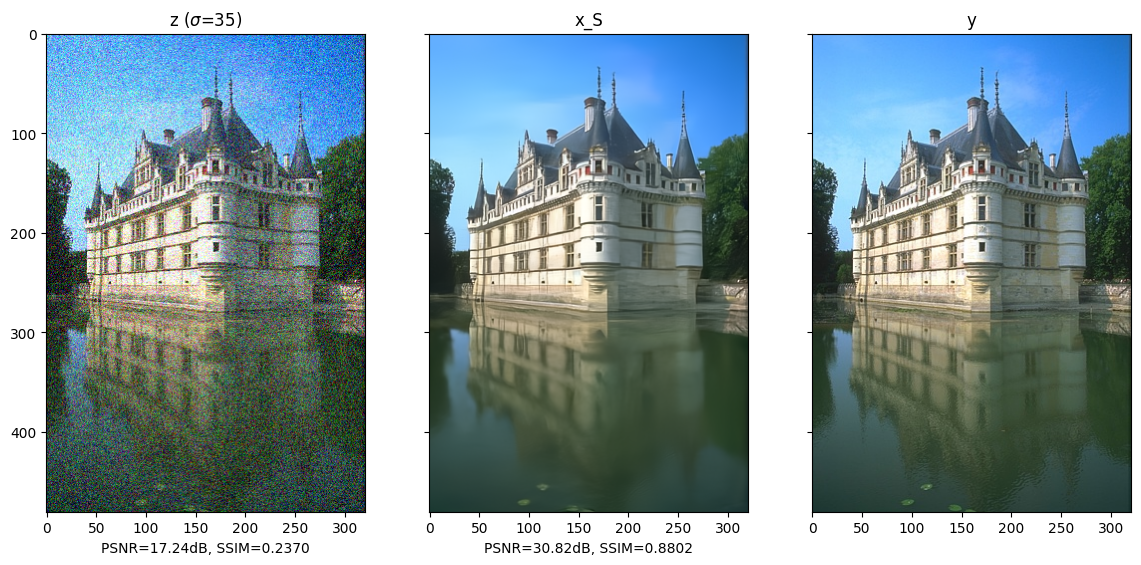

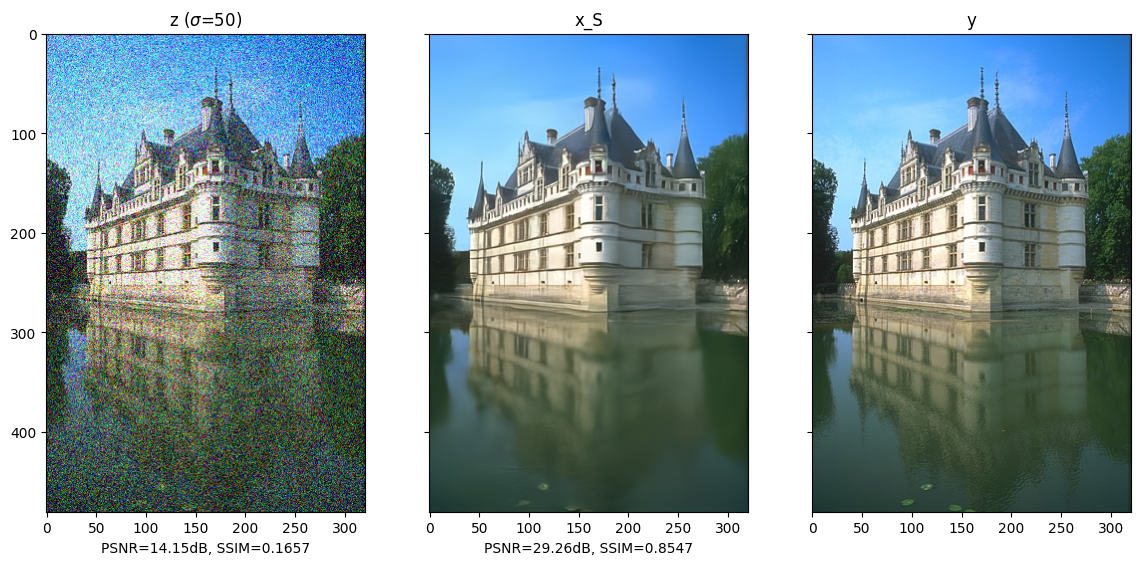

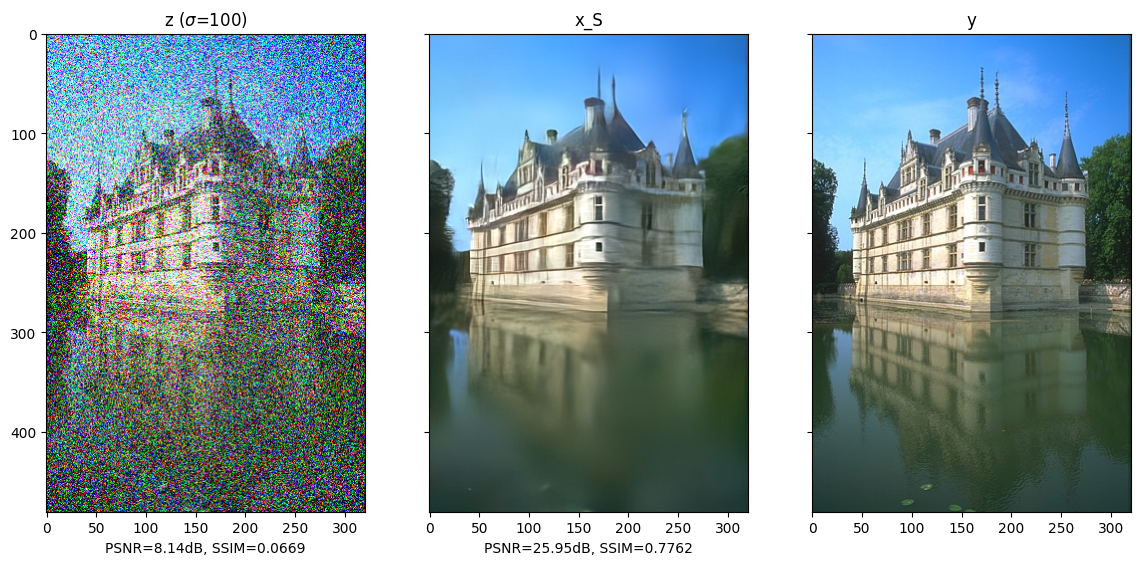

In [ ]:
# Test some sigma values
x_psnr = []
z_psnr = []
sigmas = [5, 15, 25, 35, 50, 100]

for sigma in sigmas:
    img_path = os.path.join('..', 'data', 'water-castle.png')
    z, x, y = test_img(vn, img_path, sigma= sigma)
    x_psnr.append(psnr(x, y))
    z_psnr.append(psnr(z, y))
    plot_results(z, x, y, sigma = sigma)

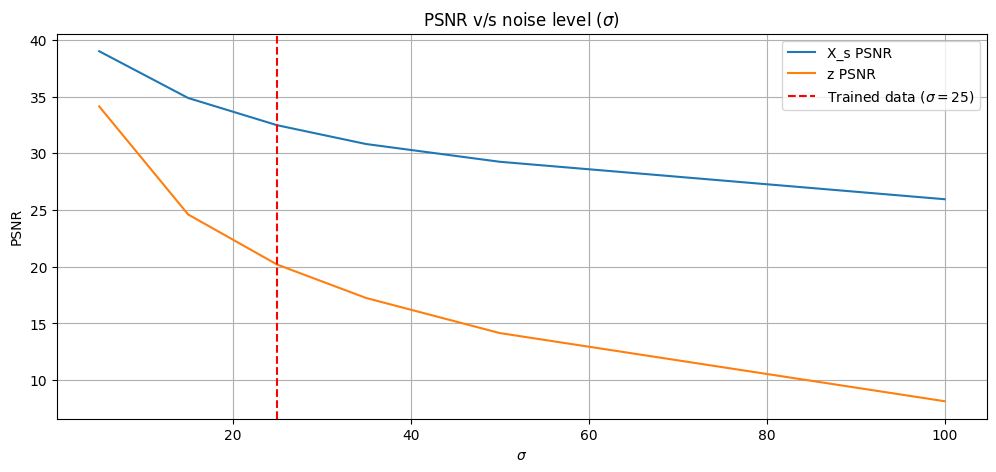

In [40]:
# plot psnr
plt.figure(figsize=(12, 5))

plt.plot(sigmas, x_psnr, label='X_s PSNR')
plt.plot(sigmas, z_psnr, label='z PSNR')
plt.axvline(x=25, linestyle='--',label=rf'Trained data ($\sigma=25$)', color="red")

plt.title(rf'PSNR v/s noise level ($\sigma$)')
plt.xlabel(rf'$\sigma$')
plt.ylabel('PSNR')
plt.grid(True)

plt.legend()
plt.show()

## S values

## T values